<a href="https://colab.research.google.com/github/hemashree2007/PORTFOLIO/blob/main/loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("10_loan_approval.csv")

df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
0,28.0,12.64,613.0,8.93,3.0,1
1,57.0,19.80,753.0,28.22,3.0,1
2,35.0,20.54,787.0,18.94,1.0,1
3,59.0,18.87,816.0,11.61,1.0,1
4,62.0,11.63,553.0,5.23,3.0,1


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())

Shape: (1020, 6)

Columns:
Index(['age', 'income_lakh', 'credit_score', 'loan_amount_lakh',
       'existing_loans', 'approved'],
      dtype='object')

Data Types:
age                 float64
income_lakh         float64
credit_score        float64
loan_amount_lakh    float64
existing_loans      float64
approved              int64
dtype: object

Statistics:
               age  income_lakh  credit_score  loan_amount_lakh  \
count  1009.000000  1010.000000   1010.000000       1010.000000   
mean     42.448959    13.453802    644.527723         15.857168   
std      12.753447     6.949768    119.393453          8.273434   
min      15.000000    -5.000000    450.000000          1.040000   
25%      31.000000     7.372500    539.000000          8.995000   
50%      42.000000    13.765000    643.000000         15.860000   
75%      53.000000    19.387500    744.750000         22.900000   
max      64.000000    24.990000   1000.000000         29.960000   

       existing_loans     approved  

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age                 11
income_lakh         10
credit_score        10
loan_amount_lakh    10
existing_loans      10
approved             0
dtype: int64

Duplicate Rows:
20


In [4]:
print("Unrealistic Ages")
print(df[(df['age'] < 18) | (df['age'] > 100)])

print("\nInvalid Credit Scores")
print(df[(df['credit_score'] < 300) | (df['credit_score'] > 900)])

print("\nNegative Income")
print(df[df['income_lakh'] < 0])

print("\nNegative Existing Loans")
print(df[df['existing_loans'] < 0])

Unrealistic Ages
      age  income_lakh  credit_score  loan_amount_lakh  existing_loans  \
123  15.0        10.15         529.0             22.10             1.0   
170  15.0        19.44         753.0             24.54             4.0   
266  15.0        19.45         831.0             27.44             3.0   
523  15.0         3.52         624.0             17.86             4.0   
555  15.0        10.64         710.0             18.01             4.0   

     approved  
123         0  
170         1  
266         1  
523         0  
555         0  

Invalid Credit Scores
       age  income_lakh  credit_score  loan_amount_lakh  existing_loans  \
21    48.0        13.17        1000.0             19.20             2.0   
80    31.0         8.47        1000.0             10.37             2.0   
225   51.0        22.82        1000.0             24.86             3.0   
976   48.0         6.57        1000.0              8.04             2.0   
1003  37.0        16.82        1000.0       

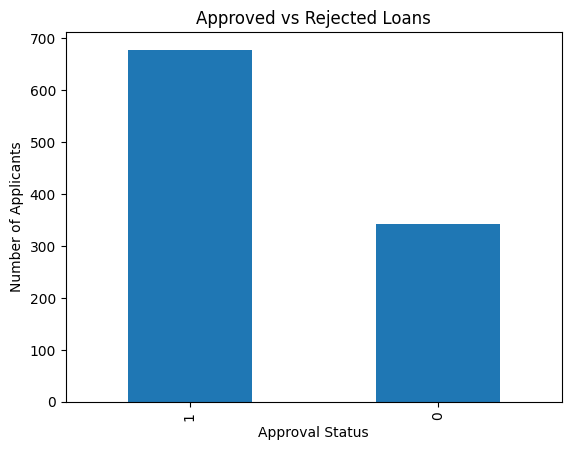

In [5]:
import matplotlib.pyplot as plt

df['approved'].value_counts().plot(kind='bar')

plt.title("Approved vs Rejected Loans")
plt.xlabel("Approval Status")
plt.ylabel("Number of Applicants")

plt.show()

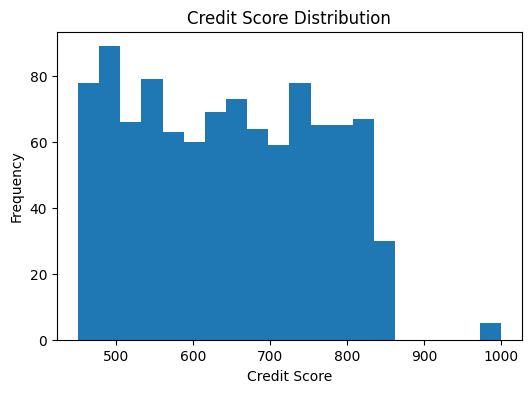

In [6]:
plt.figure(figsize=(6,4))
plt.hist(df['credit_score'], bins=20)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

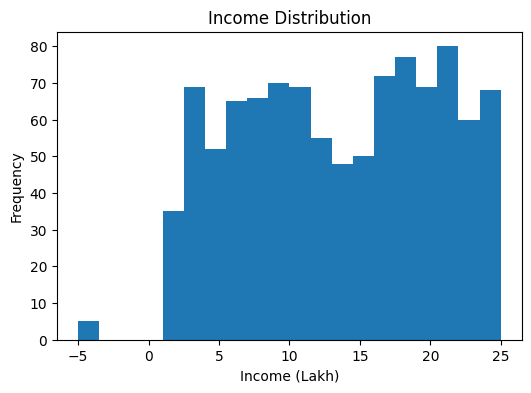

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df['income_lakh'], bins=20)

plt.title("Income Distribution")
plt.xlabel("Income (Lakh)")
plt.ylabel("Frequency")

plt.show()

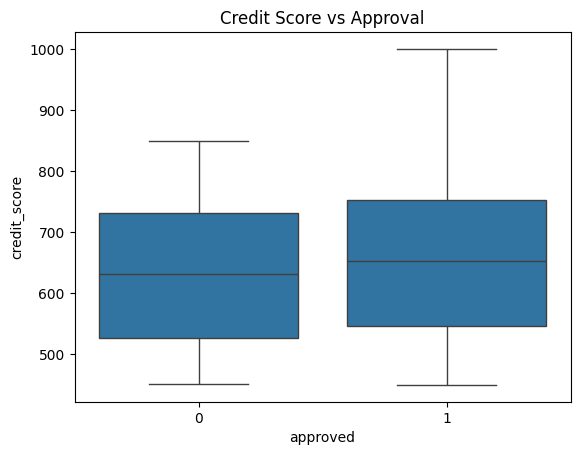

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='approved', y='credit_score', data=df)
plt.title("Credit Score vs Approval")
plt.show()

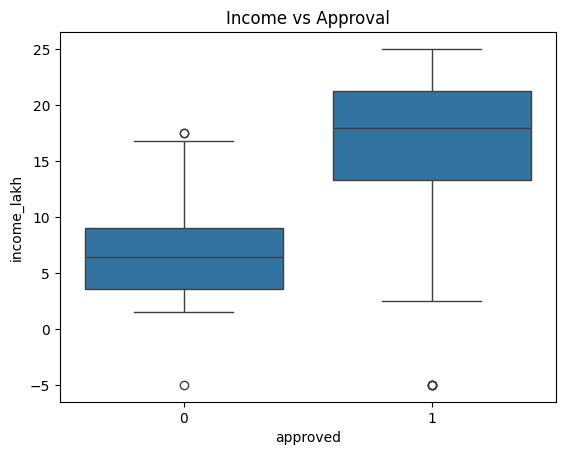

In [9]:
sns.boxplot(x='approved', y='income_lakh', data=df)
plt.title("Income vs Approval")
plt.show()

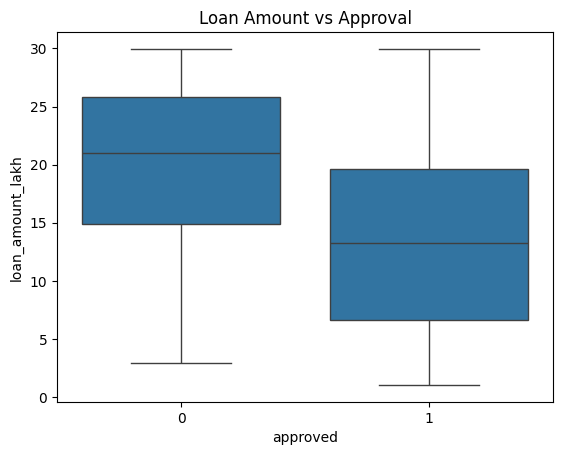

In [10]:
sns.boxplot(x='approved', y='loan_amount_lakh', data=df)
plt.title("Loan Amount vs Approval")
plt.show()

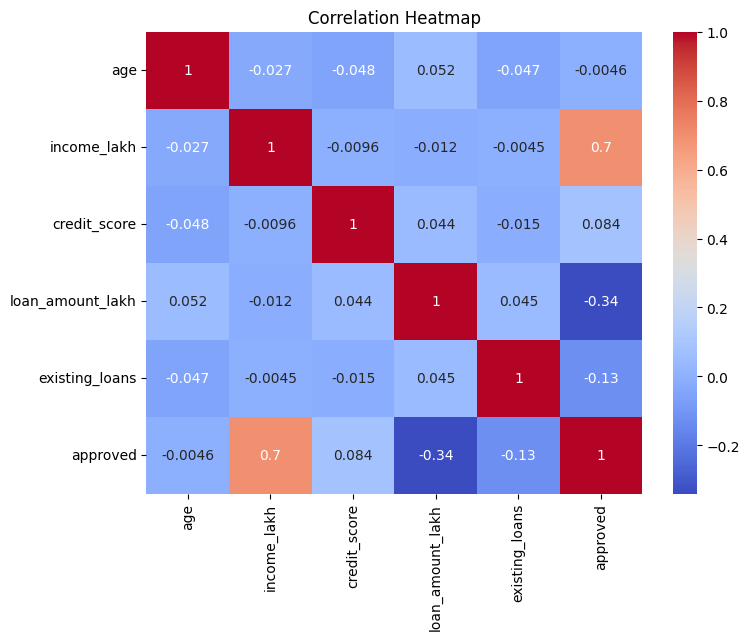

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [12]:
df = df.drop_duplicates()

df = df.dropna()

df = df[(df['age'] >= 18) &
        (df['age'] <= 100)]

df = df[(df['credit_score'] >= 300) &
        (df['credit_score'] <= 900)]

df = df[df['income_lakh'] >= 0]

df = df[df['existing_loans'] >= 0]

print(df.shape)

(931, 6)


In [13]:
df['debt_burden'] = (
    df['existing_loans'] /
    (df['income_lakh'] + 1)
)

df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved,debt_burden
0,28.0,12.64,613.0,8.93,3.0,1,0.219941
1,57.0,19.80,753.0,28.22,3.0,1,0.144231
2,35.0,20.54,787.0,18.94,1.0,1,0.046425
3,59.0,18.87,816.0,11.61,1.0,1,0.050327
4,62.0,11.63,553.0,5.23,3.0,1,0.237530


In [14]:
df['loan_income_ratio'] = (
    df['loan_amount_lakh'] /
    (df['income_lakh'] + 1)
)

df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved,debt_burden,loan_income_ratio
0,28.0,12.64,613.0,8.93,3.0,1,0.219941,0.654692
1,57.0,19.80,753.0,28.22,3.0,1,0.144231,1.356731
2,35.0,20.54,787.0,18.94,1.0,1,0.046425,0.879294
3,59.0,18.87,816.0,11.61,1.0,1,0.050327,0.584298
4,62.0,11.63,553.0,5.23,3.0,1,0.237530,0.414093


In [15]:
X = df.drop('approved', axis=1)

y = df['approved']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (931, 7)
y Shape: (931,)
